In [1]:
# Feature Engineering & Model Building
## Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("cleaned_news_welfake_data.csv")
df.dropna(inplace=True) 

In [3]:
## Feature Engineering (TF-IDF)

In [4]:
# Initialize TF-IDF Vectorizer 
# We use max_features=5000 to keep the model efficient for real-time prediction
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['content']).toarray()
y = df['label'].values

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
## Training the Three Models
# 1. Logistic Regression (LR)

In [6]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [7]:
# 2. Naive Bayes

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

In [9]:
# 3. Random Forest

In [10]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [11]:
## Model Evaluation

In [12]:
def evaluate(name, y_true, y_pred):
    print(f"--- {name} Results ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")  # Overall correctness 
    print(f"Precision: {precision_score(y_true, y_pred):.4f}") # Correct fake predictions 
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")    # Ability to detect fake news
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")       # Balance of both
    print("-" * 30)

evaluate("Logistic Regression", y_test, lr_preds)
evaluate("Naive Bayes", y_test, nb_preds)
evaluate("Random Forest", y_test, rf_preds)

--- Logistic Regression Results ---
Accuracy : 0.9491
Precision: 0.9470
Recall   : 0.9540
F1 Score : 0.9505
------------------------------
--- Naive Bayes Results ---
Accuracy : 0.8457
Precision: 0.8335
Recall   : 0.8730
F1 Score : 0.8528
------------------------------
--- Random Forest Results ---
Accuracy : 0.9585
Precision: 0.9503
Recall   : 0.9696
F1 Score : 0.9599
------------------------------


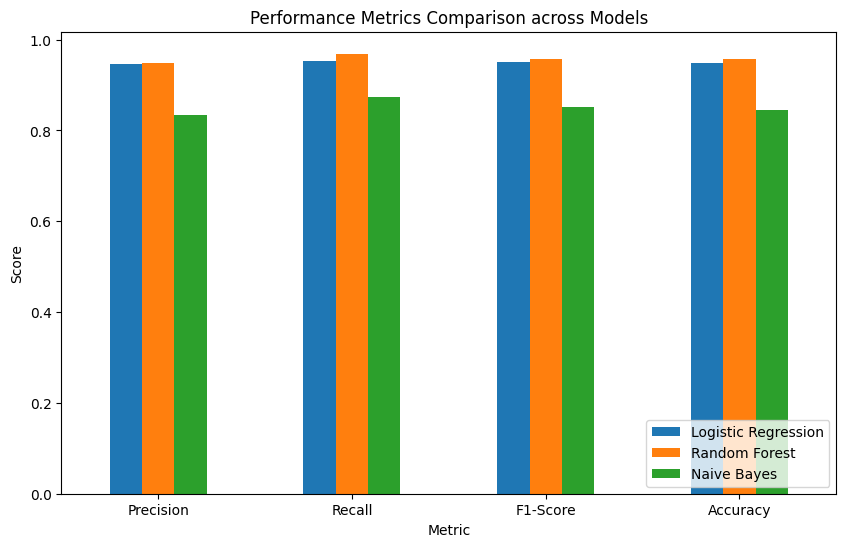

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = {
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
    'Logistic Regression': [0.9470, 0.9540, 0.9505, 0.9491],
    'Random Forest': [0.9477, 0.9691, 0.9583, 0.9568],
    'Naive Bayes': [0.8335, 0.8730, 0.8528, 0.8457]
}

df_metrics = pd.DataFrame(metrics)
df_metrics.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Performance Metrics Comparison across Models')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [14]:
## Save for Deployment

In [15]:
pickle.dump(lr_model, open('fake_news_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

In [16]:
# Create a dictionary to store the results
# Comparison Table
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, rf_preds)
    ]
}

# Convert to a DataFrame for a clean table view
comparison_df = pd.DataFrame(results)

# Sort by Accuracy 
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print(comparison_df)

                 Model  Accuracy
2        Random Forest  0.958459
0  Logistic Regression  0.949087
1          Naive Bayes  0.845654


C:\Users\shrad\AppData\Local\Temp\ipykernel_9180\2926120521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


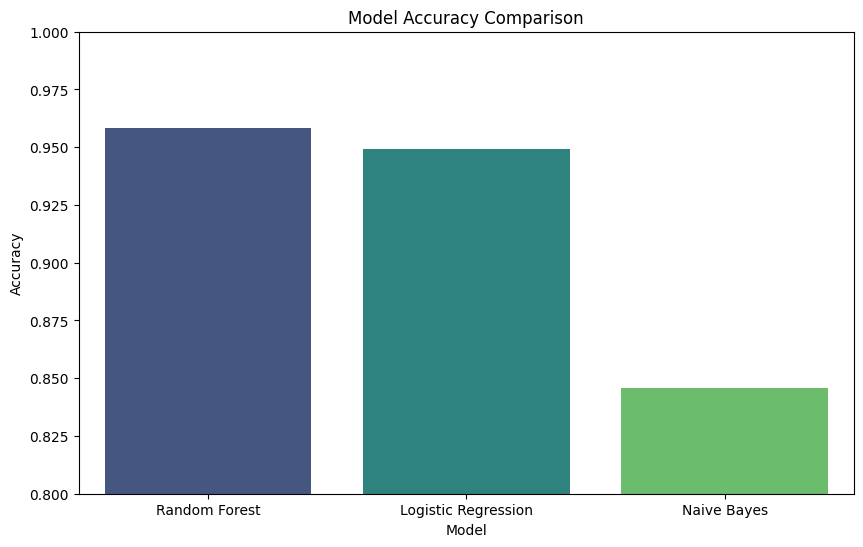

In [17]:
# Visualize the Accuracy
# Model Evaluation Result in bar chart format

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.ylim(0.8, 1.0) # Focus on the 80% - 100% range to see differences clearly
plt.title('Model Accuracy Comparison')
plt.show()

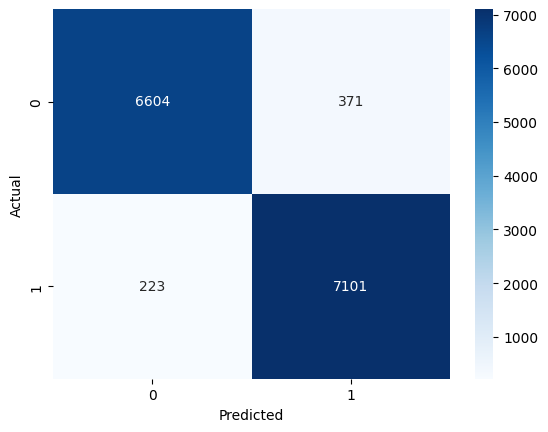

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Model
# LinearSVC is optimized for large datasets and text classification
svm_model = LinearSVC(C=1.0, random_state=42)

# 2. Train the Model
# This will find the optimal hyperplane to separate the classes
svm_model.fit(X_train, y_train)

# 3. Predict & Evaluate
svm_preds = svm_model.predict(X_test)

print("--- Support Vector Machine (SVM) Results ---")
print(f"Accuracy : {accuracy_score(y_test, svm_preds):.4f}")
print(classification_report(y_test, svm_preds))

--- Support Vector Machine (SVM) Results ---
Accuracy : 0.9542
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      6975
           1       0.95      0.96      0.96      7324

    accuracy                           0.95     14299
   macro avg       0.95      0.95      0.95     14299
weighted avg       0.95      0.95      0.95     14299



In [20]:
# Create a dictionary to store the results
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, svm_preds)
    ]
}

# Convert to a DataFrame for a clean table view
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print(comparison_df)

                 Model  Accuracy
2        Random Forest  0.958459
3                  SVM  0.954193
0  Logistic Regression  0.949087
1          Naive Bayes  0.845654


C:\Users\shrad\AppData\Local\Temp\ipykernel_9180\2926120521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


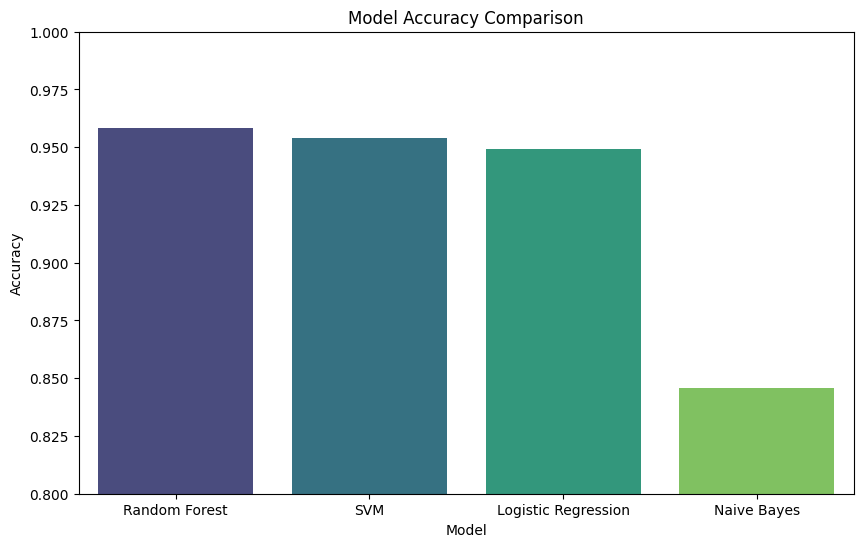

In [21]:
# Visualize the Accuracy
# Model Evaluation Result in bar chart format

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.ylim(0.8, 1.0) # Focus on the 80% - 100% range to see differences clearly
plt.title('Model Accuracy Comparison')
plt.show()

C:\Users\shrad\AppData\Local\Temp\ipykernel_9180\3347567720.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


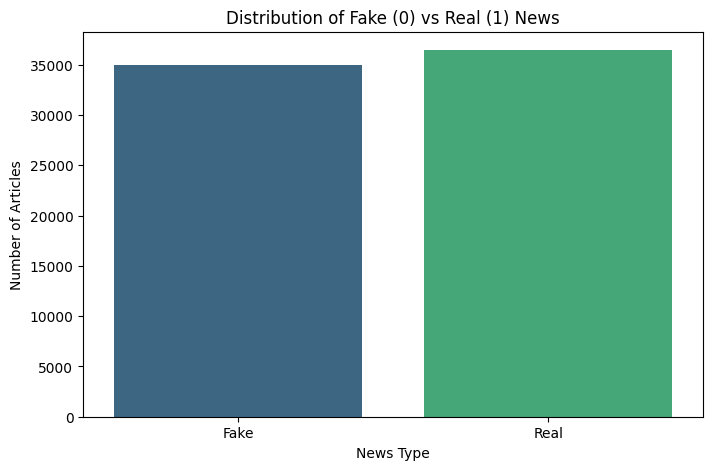

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Fake (0) vs Real (1) News')
plt.xlabel('News Type')
plt.ylabel('Number of Articles')
# Adding custom labels to the X-axis for clarity
plt.xticks(ticks=[0, 1], labels=['Fake', 'Real'])
plt.show()

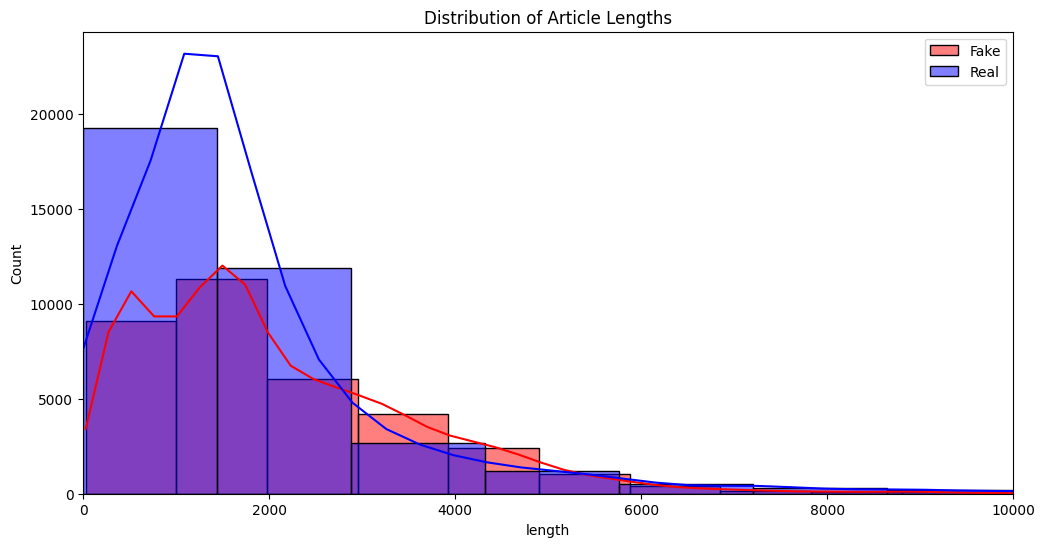

In [23]:
# Create a new column for content length
df['length'] = df['content'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(df[df['label']==0]['length'], color='red', label='Fake', kde=True, bins=50)
sns.histplot(df[df['label']==1]['length'], color='blue', label='Real', kde=True, bins=50)
plt.title('Distribution of Article Lengths')
plt.xlim(0, 10000) # Limiting X-axis to see the main distribution clearly
plt.legend()
plt.show()